# Loan clustering

In this notebook, we will analyse the German credit dataset, which was originally created by Hans Hofmann in 1994, and contains registries of loans made in a bank in German at that time. Our goal is to **cluster profiles of loans in the bank**. The dataset was obtained in https://www.kaggle.com/datasets/uciml/german-credit on 2026-08-05.

## Importing libraries and data loading

These are the libraries we will use:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

We will load the CSV file with all the data:

In [2]:
df = pd.read_csv('german_credit_data.csv')

## Exploratory Data Analysis (EDA)

### Data cleaning

We see if there are any duplicated data:

In [3]:
df.duplicated().any()

np.False_

There are **no duplicated data**. Let's see if there are null values:

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 103.7 KB


As we can see, there are **1000 entries** (a good amount), but there are 183 people with empty registry on saving accounts and 394 people with the same situation on checking accounts. This is a very significative part of the entire dataset (18.3% and 39.4%). Plus, there's a column, named 'unnamed', representing the IDs, that can be ignored. So, we run this command to discard that specific column:

In [5]:
df = df.drop(columns=['Unnamed: 0'])

And we take a look at the possible data on the saving accounts and checking accounts columns:

In [6]:
print(df['Saving accounts'].value_counts(dropna=False))
print("\n")
print(df['Checking account'].value_counts(dropna=False))

Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64


Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64


So, we could interpret **'NaN' simply as the client does not have that kind of account in the bank**, and the other adjectives, such as 'moderate' and 'rich', describe, without numbers, the amount of money in the clients' accounts. However, let's look into the existence of people without both accounts:

In [7]:
len(df[df['Saving accounts'].isna() & df['Checking account'].isna()])

99

This number is very expressive, as it's approximately 10% of the number of entries in the dataset. Therefore, we simply cannot drop data, we treat the absence of info on the saving accounts and checking accounts as lack of these kinds of accounts in the bank. It means the person is asking for a loan without having account in the bank in which he/she is asking for. So, the person can be a client of other bank too. Let's consider the lack of info as **'no account'**:

In [8]:
df['Saving accounts'] = df['Saving accounts'].fillna('no account')
df['Checking account'] = df['Checking account'].fillna('no account')

### Univariate analysis

#### Analyzing age

In [9]:
print(df['Age'].describe())
print("\n")

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64




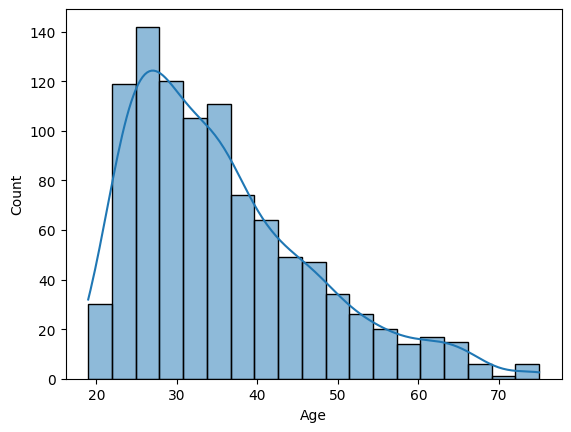

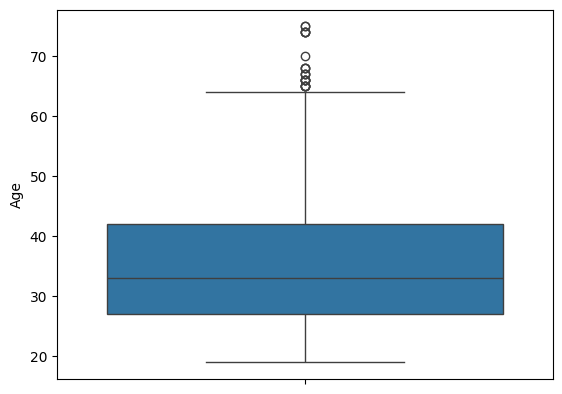

In [10]:
sns.histplot(data=df, x='Age', kde=True)
plt.show()

sns.boxplot(data=df, y='Age')
plt.show()

This reveals us that the common profile of the loans is made by **young** clients.

#### Analyzing sex

In [11]:
print(df['Sex'].value_counts())
print("\n")

Sex
male      690
female    310
Name: count, dtype: int64




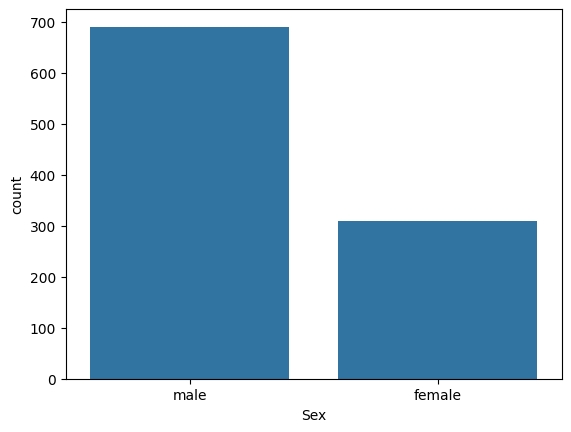

In [12]:
sns.countplot(data=df, x='Sex')
plt.show()

69% of the loans were made by men and 31% by women. This shows us that the profile of the common loan has a **masculine** source, but there is a significative feminine presence in the dataset.

#### Analyzing job

In [13]:
print(df['Job'].value_counts())
print("\n")

Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64




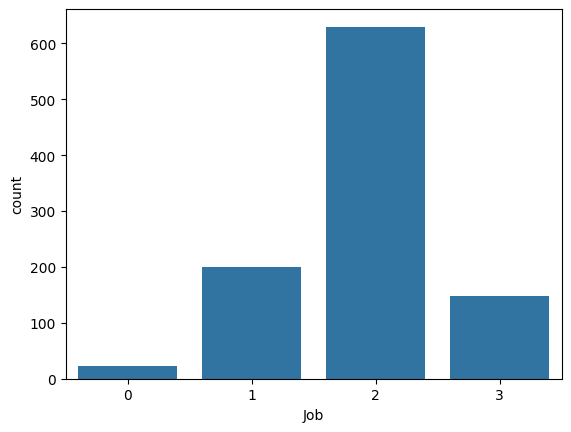

In [14]:
sns.countplot(data=df, x='Job')
plt.show()

In the dataset, the value 0 for job means 'unskilled and non-resident', 1 'unskilled and resident', 2 'skilled' and 3 'highly skilled'. Therefore, most of the clients of the bank are **skilled or highly skilled (77.8%)**.

#### Analyzing housing

In [15]:
print(df['Housing'].value_counts())
print("\n")

Housing
own     713
rent    179
free    108
Name: count, dtype: int64




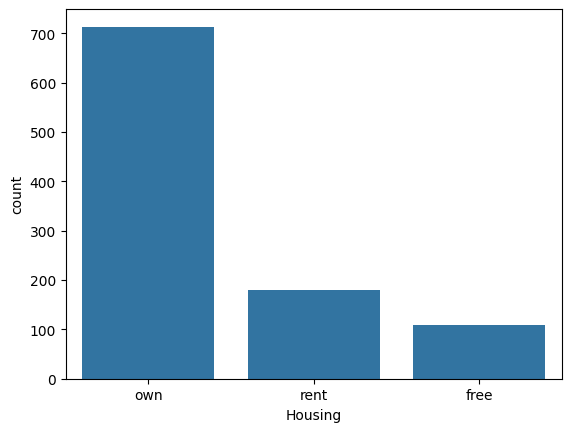

In [16]:
sns.countplot(data=df, x='Housing', order=df['Housing'].value_counts().index)
plt.show()

Most clients have their **own home (71.3%)**, and the numbers of people that live in a rented place and in a spot that are not theirs, but they don't pay for living in that location, are close. 

#### Analyzing saving accounts

In [17]:
print(df['Saving accounts'].value_counts())
print("\n")

Saving accounts
little        603
no account    183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64




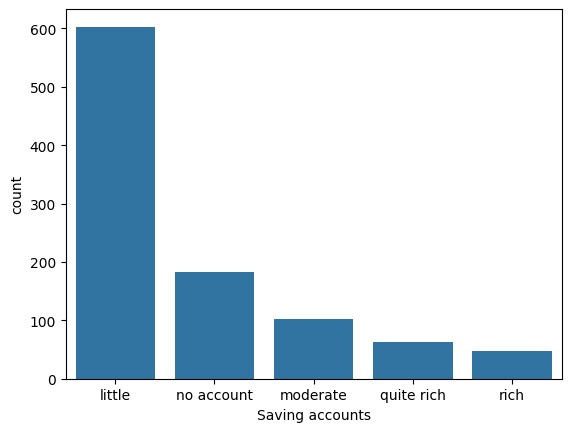

In [18]:
sns.countplot(data=df, x='Saving accounts', order=df['Saving accounts'].value_counts().index)
plt.show()

Most clients have **little or no saving accounts (78.6%)**. Just a few (11.1%) are rich or quite rich, which is a little greater than people with moderate money in saving accounts (10.3%).

#### Analyzing checking account

In [19]:
print(df['Checking account'].value_counts())
print("\n")

Checking account
no account    394
little        274
moderate      269
rich           63
Name: count, dtype: int64




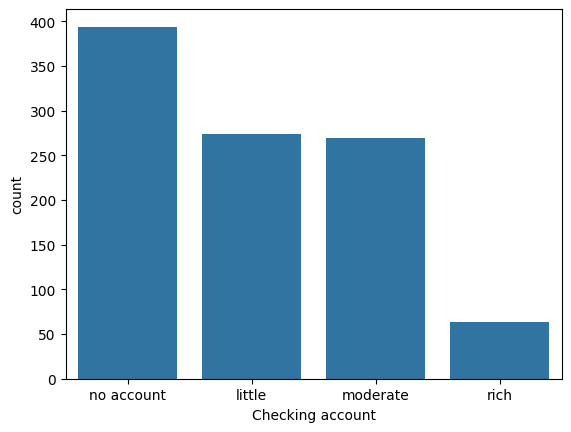

In [20]:
sns.countplot(data=df, x='Checking account', order=df['Checking account'].value_counts().index)
plt.show()

Regarding checking account, **most clients (66.8%) don't have it or have just a small amount of money**. The number of 'moderate' is approximately the number of 'little', and 'rich' is not common.

#### Analyzing credit amount

In [21]:
print(df['Credit amount'].describe())
print("\n")

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64




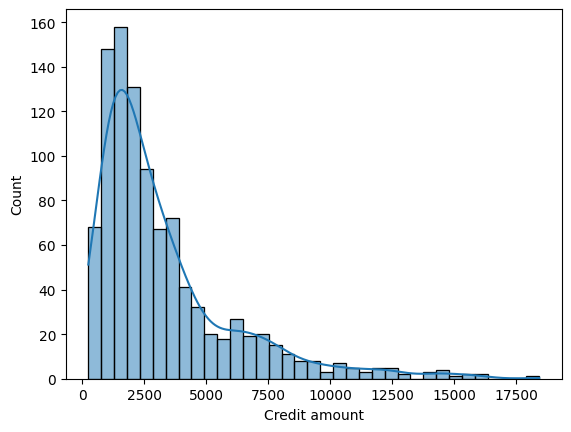

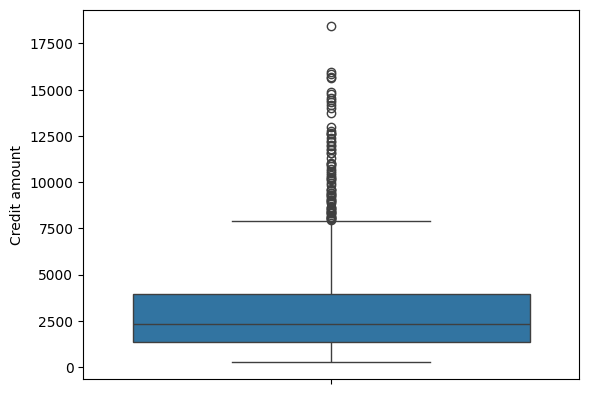

In [22]:
sns.histplot(data=df, x='Credit amount', kde=True)
plt.show()

sns.boxplot(data=df, y='Credit amount')
plt.show()

Credit amount is given in DM (Deutsch Mark). There are **many outliers with credits above 7500**, when 75% of the loans are less than 3972.25. We notice nested outliers.

#### Analyzing duration

In [23]:
print(df['Duration'].describe())
print("\n")

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration, dtype: float64




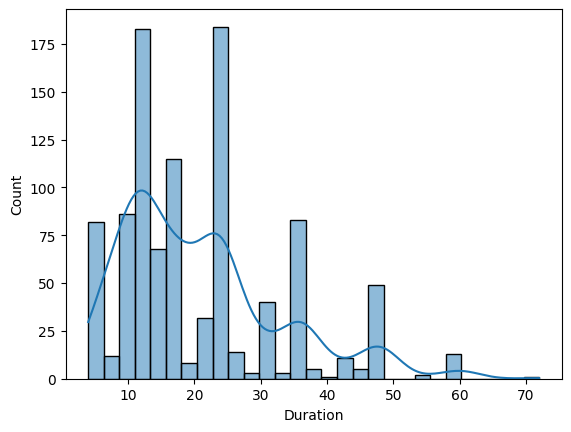

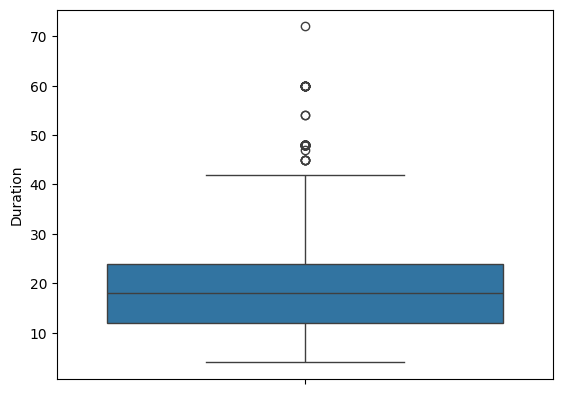

In [24]:
sns.histplot(data=df, x='Duration', kde=True)
plt.show()

sns.boxplot(data=df, y='Duration')
plt.show()

Duration is given in months. Again, we notice the presence of outliers, but they come in less number comparing to the credit amount. And we see peaks at 5 regions.

#### Analyzing purpose

In [25]:
print(df['Purpose'].value_counts())

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64


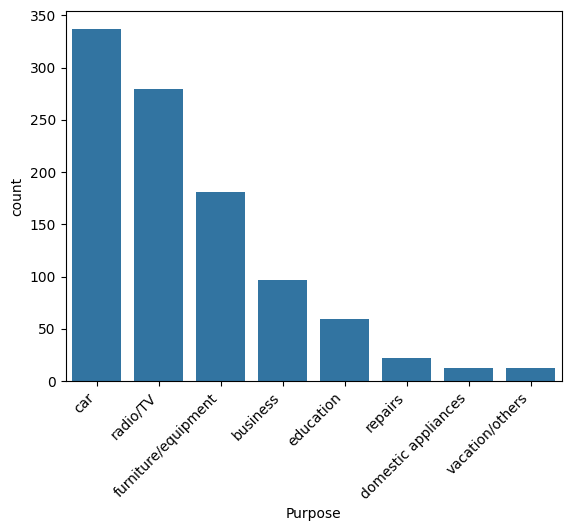

In [26]:
sns.countplot(data=df, x='Purpose', order=df['Purpose'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.show()

The purposes of the loans are **diverse**. Some of them require naturally more duration and credit amount, such as 'car' and 'business', while others, as 'radio/TV', don't.

### Multivariate analysis

#### Analyzing credit amount, duration and purpose

In [27]:
print("Considering credit amount and purpose:\n\n")
df.groupby('Purpose')['Credit amount'].describe()

Considering credit amount and purpose:




,count,mean,std,min,25%,50%,75%,max
Purpose,,,,,,,,
business,97.0,4158.041237,3231.484456,609.0,1908.00,3161.0,5293.00,15945.0
car,337.0,3768.192878,3123.594488,250.0,1364.00,2679.0,5248.00,14896.0
domestic appliances,12.0,1498.000000,1012.510741,343.0,1131.25,1249.0,1359.50,3990.0
education,59.0,2879.203390,2883.916266,339.0,936.50,1597.0,3638.00,12612.0
furniture/equipment,181.0,3066.988950,2034.146228,428.0,1747.00,2578.0,3643.00,14179.0
radio/TV,280.0,2487.653571,2073.693150,338.0,1261.00,1890.0,3038.00,15653.0
repairs,22.0,2728.090909,2627.490364,454.0,1214.50,1749.0,3203.25,11998.0
vacation/others,12.0,8209.333333,6112.703156,1164.0,2410.50,6948.0,12649.00,18424.0


Vacation/others has **very huge numbers** compared to other purposes, which tend to be closer to each other.

In [28]:
print("Considering duration and purpose:\n\n")
df.groupby('Purpose')['Duration'].describe()

Considering duration and purpose:




,count,mean,std,min,25%,50%,75%,max
Purpose,,,,,,,,
business,97.0,26.938144,13.307121,5.0,18.00,24.0,36.00,60.0
car,337.0,20.813056,11.980046,4.0,12.00,18.0,24.00,60.0
domestic appliances,12.0,16.833333,12.575831,6.0,9.75,13.5,15.75,48.0
education,59.0,19.677966,13.268371,6.0,11.00,12.0,24.00,60.0
furniture/equipment,181.0,19.292818,9.421453,4.0,12.00,18.0,24.00,48.0
radio/TV,280.0,20.046429,12.171180,4.0,12.00,18.0,24.00,72.0
repairs,22.0,19.090909,9.865327,6.0,12.00,16.5,24.00,42.0
vacation/others,12.0,32.333333,15.393820,8.0,24.00,24.0,48.00,60.0


When **we descard credit amount and consider only duration**, all purposes, including vacation/others, tend to be closer to each other.

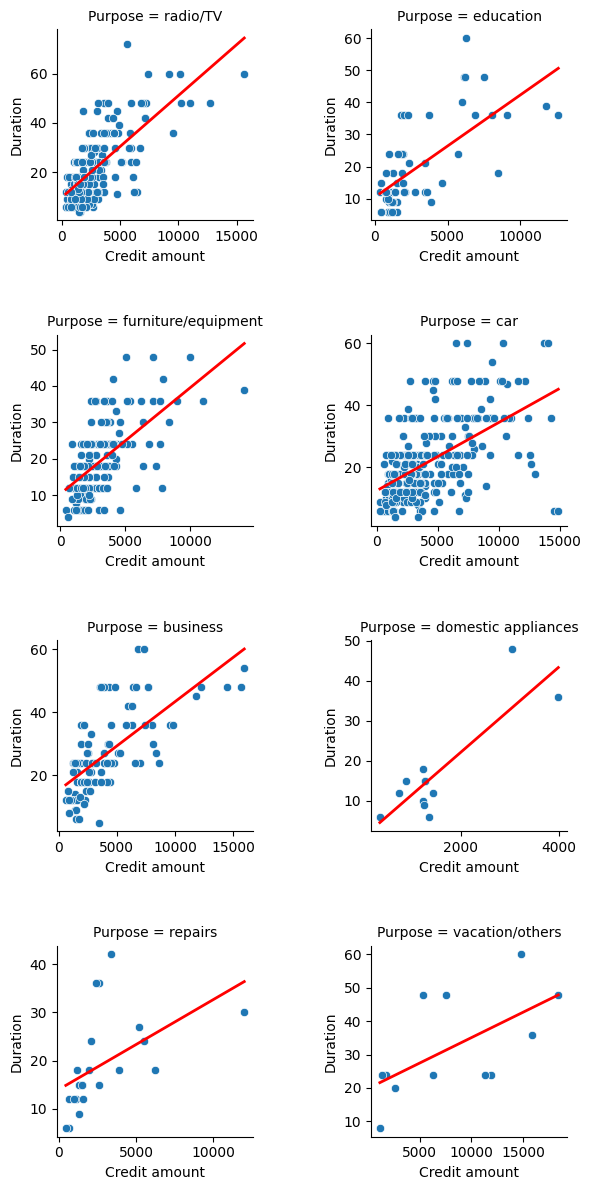

In [29]:
def plot_scatter(x, y, **kwargs):
    sns.scatterplot(x=x, y=y)
    sns.regplot(
        x=x,
        y=y,
        scatter=False,
        color="red",
        ci=None,
        line_kws={"linewidth": 2},
    )

g = sns.FacetGrid(df, col="Purpose", col_wrap=2, sharex=False, sharey=False)
g.map(plot_scatter, "Credit amount", "Duration")

for i in g.axes.flat:
    i.set_xlabel("Credit amount")
    i.set_ylabel("Duration")

g.fig.subplots_adjust(hspace=0.6, wspace=0.6)

plt.show()

With these data, we can infer that:
 - The durations tend to grow when the credit amounts goes up.
 - The rate of this growing depends on the the kind of purpose.

## Data preprocessing

Now, in order to cluster, we need to turn some qualitative variables into quantitative ones. So, we use **One-Hot Encoding** and **Ordinal Encoding**.

Job is already encoded in the dataset.

In [30]:
pp_df = df.copy()

pp_df = pd.get_dummies(pp_df, columns=['Sex', 'Purpose'], drop_first=True)

pp_df['Saving accounts'] = pp_df['Saving accounts'].map({'no account': 0, 'little': 1, 'moderate': 2, 'rich': 3, 'quite rich': 4})
pp_df['Checking account'] = pp_df['Checking account'].map({'no account': 0, 'little': 1, 'moderate': 2, 'rich': 3})
pp_df['Housing'] = pp_df['Housing'].map({'rent': 1, 'free': 2, 'own': 3})

And we need to standard our data. So, we use **StandardScaler**.

In [31]:
pp_df[['Age', 'Credit amount', 'Duration']] = StandardScaler().fit_transform(pp_df[['Age', 'Credit amount', 'Duration']])

Let's take a brief look at our dataframe:

In [32]:
pp_df.head()

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Sex_male,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,2.766456,2,3,0,1,-0.745131,-1.236478,True,False,False,False,False,True,False,False
1,-1.191404,2,3,1,2,0.949817,2.248194,False,False,False,False,False,True,False,False
2,1.183312,1,3,1,0,-0.416562,-0.738668,True,False,False,True,False,False,False,False
3,0.831502,2,2,1,1,1.634247,1.750384,True,False,False,False,True,False,False,False
4,1.535122,2,2,1,1,0.566664,0.256953,True,True,False,False,False,False,False,False


## Clustering

### Finding the clusters

After all the previous activities, it's time to start the clustering process. Therefore, let's run the **PCA**.

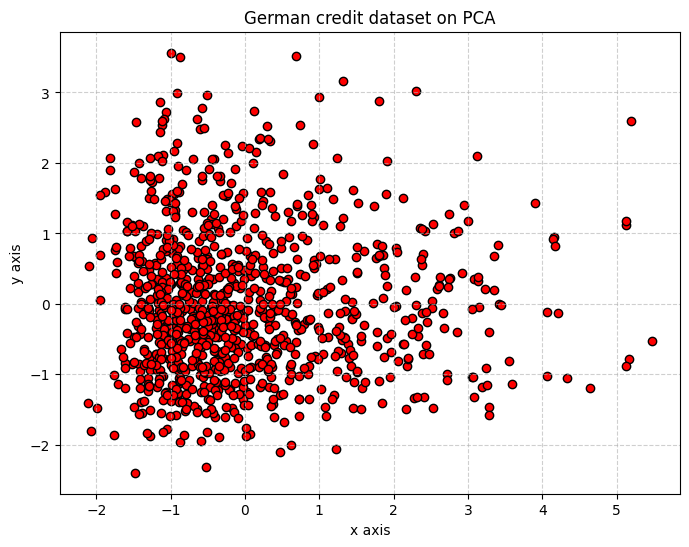

In [33]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(pp_df)

plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c='red', edgecolors='k')

plt.title('German credit dataset on PCA')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

PCA gave us a scatterplot with **too many concentrated points**. It means the vast majority of the loans in the bank tend to follow a standard characteristic: the profile of the loans is **homogeneous**. Let us run DBSCAN to find the clusters:

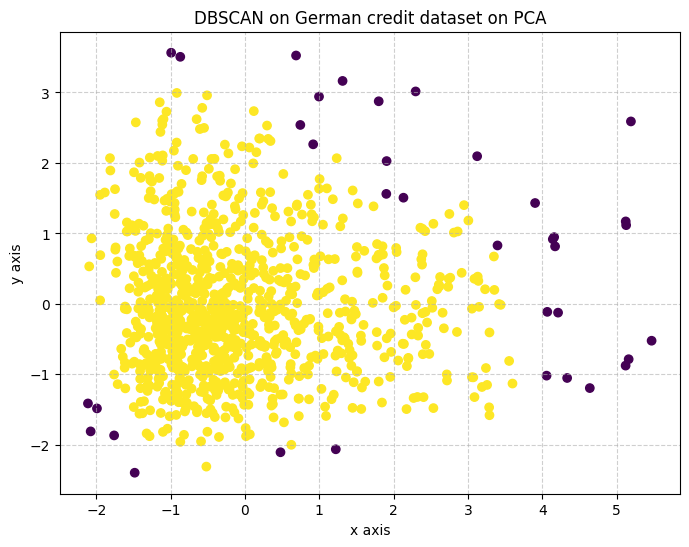

In [34]:
dbscan = DBSCAN(eps=0.4)

clusters = dbscan.fit_predict(pca_data)

plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters, cmap='viridis')

plt.title('DBSCAN on German credit dataset on PCA')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.show()

As we can see, the 'peripherical' points are part of a **minor cluster**, and all the other points, the vast majority of registries in the dataset, are in the **major cluster**. We will create two dataframes to analyse both clusters:

In [35]:
df['Cluster'] = clusters

df_group1 = df[df['Cluster'] == 0].copy()
df_group2 = df[df['Cluster'] == -1].copy()

print("Number of registries in group 1:", len(df_group1))
print("Number of registries in group 2:", len(df_group2))

Number of registries in group 1: 964
Number of registries in group 2: 36


So, approximately **96% of the loans** are in the group 1 and **4%** in the other group.

## Clusters analysis

### Analyzing age

In [73]:
print("Group 1")
print(df_group1['Age'].describe())
print("\n")

print("Group 2")
print(df_group2['Age'].describe())
print("\n")

Group 1
count    964.000000
mean      35.169087
std       10.782637
min       19.000000
25%       27.000000
50%       33.000000
75%       41.000000
max       74.000000
Name: Age, dtype: float64


Group 2
count    36.000000
mean     45.638889
std      19.642742
min      19.000000
25%      26.500000
50%      45.500000
75%      63.000000
max      75.000000
Name: Age, dtype: float64




Group 1


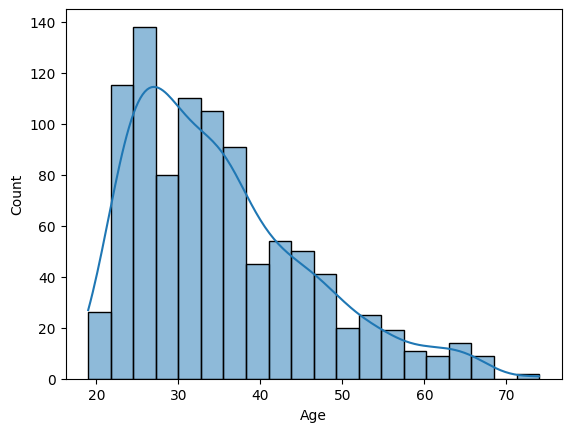

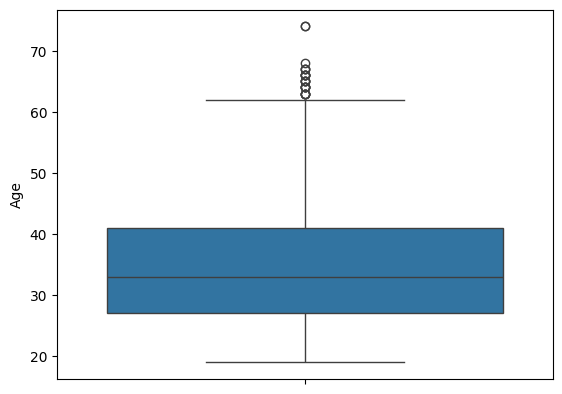


Group 2


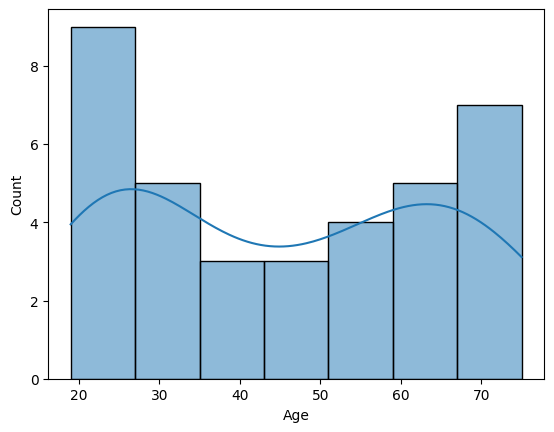

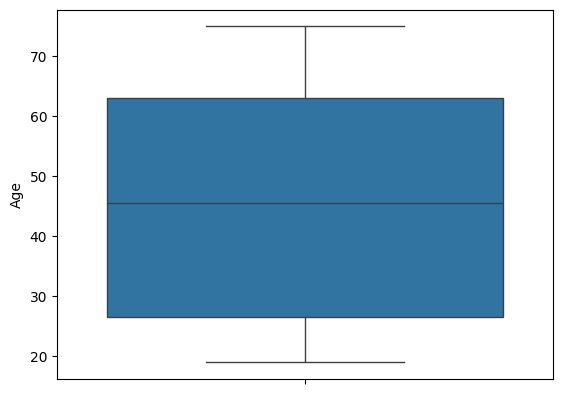

In [42]:
print("Group 1")
sns.histplot(data=df_group1, x='Age', kde=True)
plt.show()
sns.boxplot(data=df_group1, y='Age')
plt.show()

print("\nGroup 2")
sns.histplot(data=df_group2, x='Age', kde=True)
plt.show()
sns.boxplot(data=df_group2, y='Age')
plt.show()

Group 1 tends to follow the **dataset age patterns**, whereas group 2 tends to have more **different kinds of age**.

### Analyzing sex

In [74]:
print("Group 1")
print(df_group1['Sex'].value_counts())
print("\n")

print("Group 2")
print(df_group2['Sex'].value_counts())
print("\n")

Group 1
Sex
male      663
female    301
Name: count, dtype: int64


Group 2
Sex
male      27
female     9
Name: count, dtype: int64




Group 1


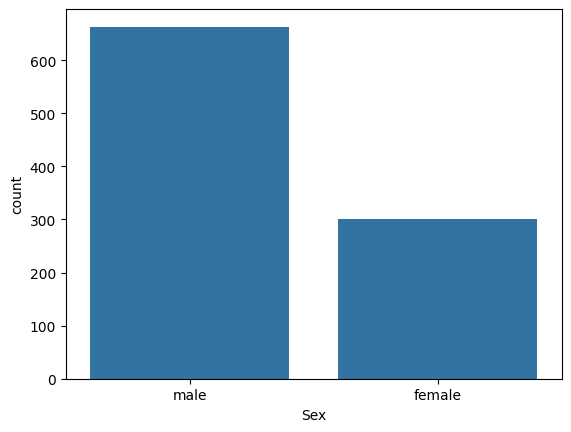

Group 2


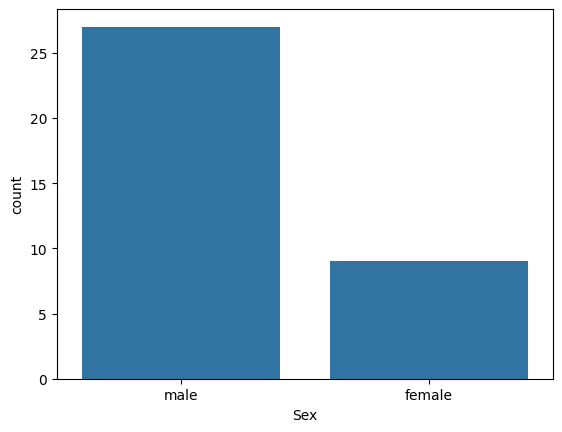

In [46]:
print("Group 1")
sns.countplot(data=df_group1, x='Sex')
plt.show()

print("Group 2")
sns.countplot(data=df_group2, x='Sex')
plt.show()

Once again, group 1 tends to follow the dataset patterns. Group 2, however, has a **slightly lesser number of loans made by women**, but the percentage does not change significantly (75% male and 25% women in group 2 versus 69% male and 31% women in the dataset).  

### Analyzing job

In [48]:
print("Group 1")
print(df_group1['Job'].value_counts())
print("\n")

print("Group 2")
print(df_group2['Job'].value_counts())
print("\n")

Group 1
Job
2    619
1    195
3    131
0     19
Name: count, dtype: int64


Group 2
Job
3    17
2    11
1     5
0     3
Name: count, dtype: int64




Group 1


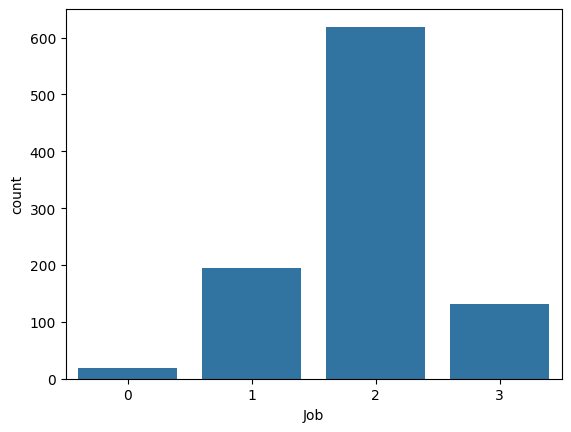

Group 2


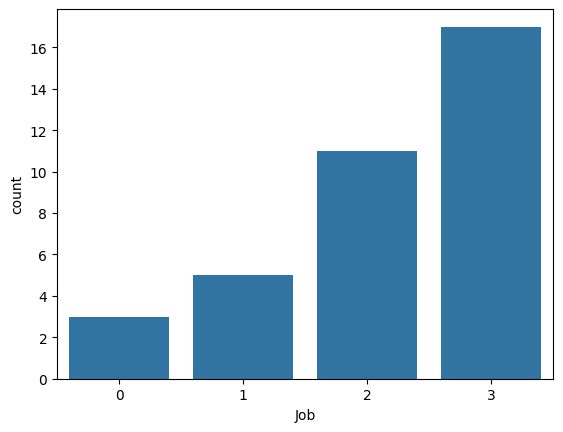

In [50]:
print("Group 1")
sns.countplot(data=df_group1, x='Job')
plt.show()

print("Group 2")
sns.countplot(data=df_group2, x='Job')
plt.show()

Group 1 continues being a mirror of the dataset. In group 2, however, the **extremes**, 3 (highly skilled) and 0 (unskilled and non-resident), **grow significantly**, while 1 and 2 decrease.

### Analyzing housing

In [52]:
print("Group 1")
print(df_group1['Housing'].value_counts())
print("\n")

print("Group 2")
print(df_group2['Housing'].value_counts())
print("\n")

Group 1
Housing
own     694
rent    171
free     99
Name: count, dtype: int64


Group 2
Housing
own     19
free     9
rent     8
Name: count, dtype: int64




Group 1


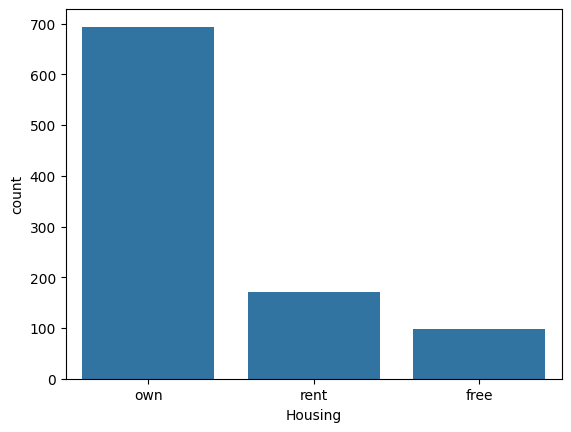

Group 2


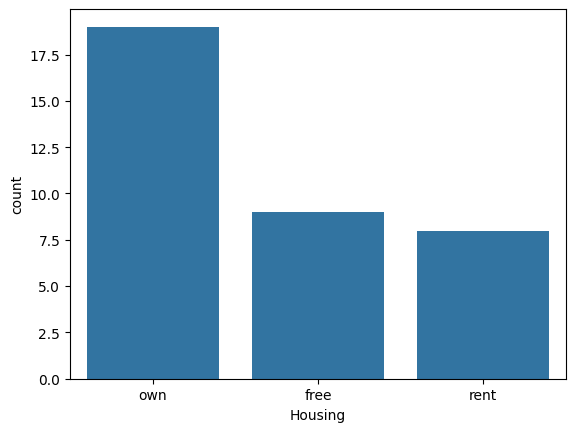

In [76]:
print("Group 1")
sns.countplot(data=df_group1, x='Housing', order=df_group1['Housing'].value_counts().index)
plt.show()

print("Group 2")
sns.countplot(data=df_group2, x='Housing', order=df_group2['Housing'].value_counts().index)
plt.show()

In group 2, 'rent' and 'free' **grow expressly**. Group 1 is still an image of all the dataset.

### Analyzing saving accounts

In [55]:
print("Group 1")
print(df_group1['Saving accounts'].value_counts())
print("\n")

print("Group 2")
print(df_group2['Saving accounts'].value_counts())
print("\n")

Group 1
Saving accounts
little        586
no account    172
moderate      100
quite rich     61
rich           45
Name: count, dtype: int64


Group 2
Saving accounts
little        17
no account    11
rich           3
moderate       3
quite rich     2
Name: count, dtype: int64




Group 1


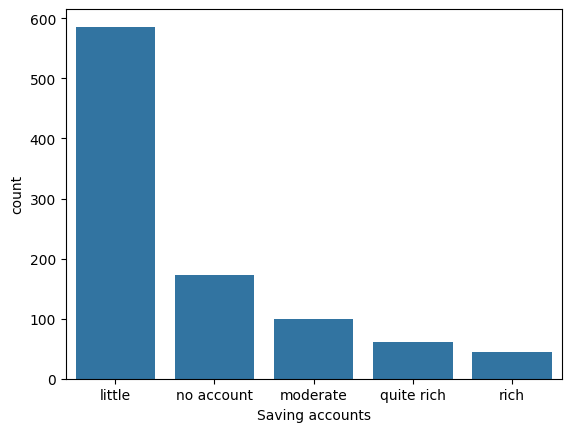

Group 2


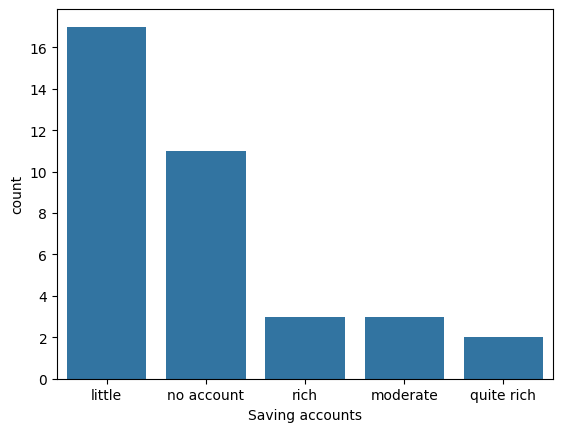

In [75]:
print("Group 1")
sns.countplot(data=df_group1, x='Saving accounts', order=df_group1['Saving accounts'].value_counts().index)
plt.show()

print("Group 2")
sns.countplot(data=df_group2, x='Saving accounts', order=df_group2['Saving accounts'].value_counts().index)
plt.show()

Group 1 is still similar to all the dataset. What we perceive in group 2 is a significant greater number of **'no accounts'**.

### Analyzing checking account

In [58]:
print("Group 1")
print(df_group1['Checking account'].value_counts())
print("\n")

print("Group 2")
print(df_group2['Checking account'].value_counts())
print("\n")

Group 1
Checking account
no account    383
little        265
moderate      254
rich           62
Name: count, dtype: int64


Group 2
Checking account
moderate      15
no account    11
little         9
rich           1
Name: count, dtype: int64




Group 1


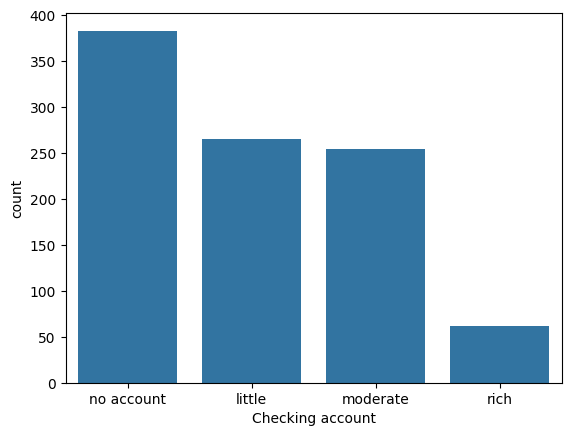

Group 2


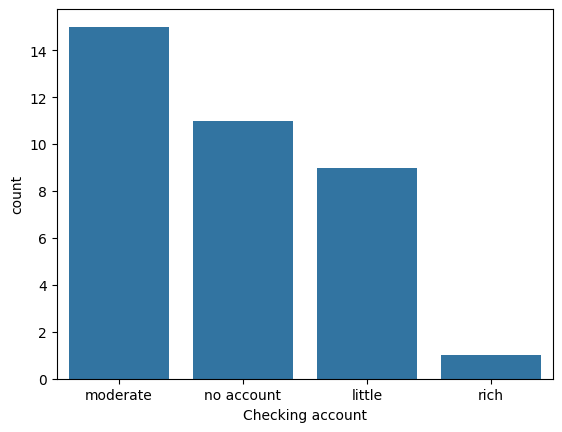

In [59]:
print("Group 1")
sns.countplot(data=df_group1, x='Checking account', order=df_group1['Checking account'].value_counts().index)
plt.show()

print("Group 2")
sns.countplot(data=df_group2, x='Checking account', order=df_group2['Checking account'].value_counts().index)
plt.show()

Still, group 1 is a mirror of the dataset. What we see in group is the **decrease of the extremes**, 'no account' and 'rich', and **the growth of 'moderate'**.

### Analyzing credit amount

In [60]:
print("Group 1")
print(df_group1['Credit amount'].describe())
print("\n")

print("Group 2")
print(df_group2['Credit amount'].describe())
print("\n")

Group 1
count      964.000000
mean      3064.962656
std       2444.357428
min        250.000000
25%       1359.500000
50%       2264.000000
75%       3851.750000
max      14555.000000
Name: Credit amount, dtype: float64


Group 2
count       36.000000
mean      8795.388889
std       5519.991171
min        433.000000
25%       3446.250000
50%       8376.500000
75%      14213.750000
max      18424.000000
Name: Credit amount, dtype: float64




Group 1


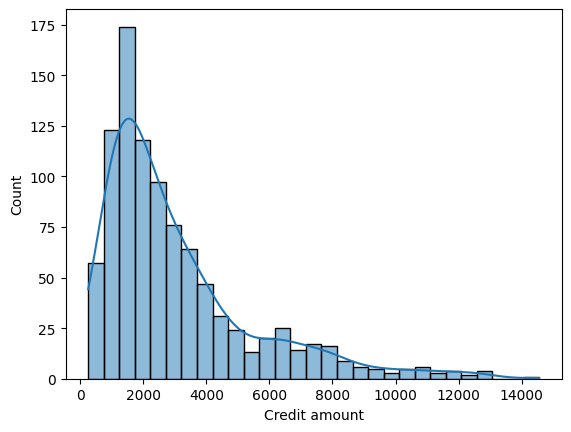

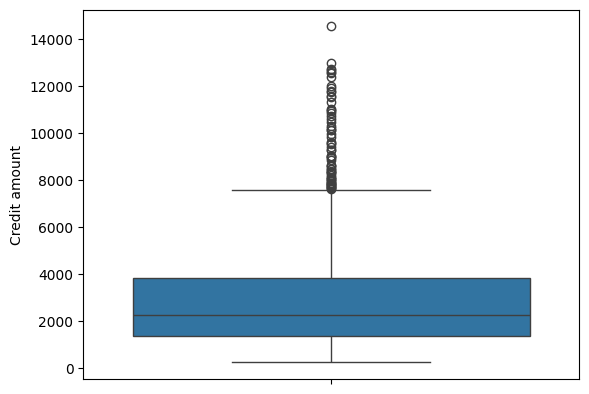

Group 2


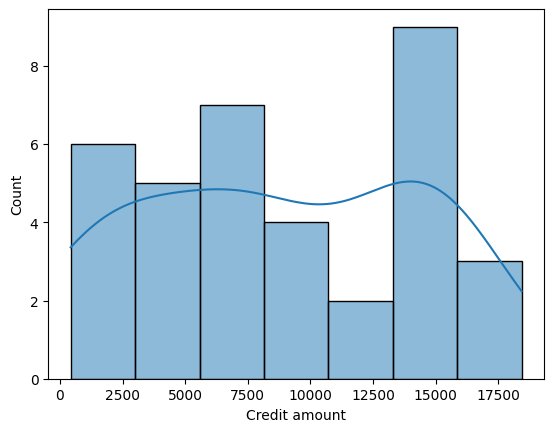

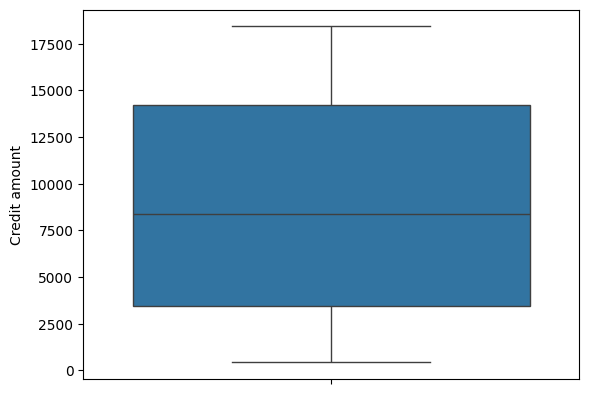

In [80]:
print("Group 1")
sns.histplot(data=df_group1, x='Credit amount', kde=True)
plt.show()
sns.boxplot(data=df_group1, y='Credit amount')
plt.show()

print("Group 2")
sns.histplot(data=df_group2, x='Credit amount', kde=True)
plt.show()
sns.boxplot(data=df_group2, y='Credit amount')
plt.show()

Once again, group 1 continues to replicate the dataset. However, now we see a **diversity of credits amounts** in group 2.

### Analyzing duration

In [63]:
print("Group 1")
print(df_group1['Duration'].describe())
print("\n")

print("Group 2")
print(df_group2['Duration'].describe())
print("\n")

Group 1
count    964.000000
mean      20.379668
std       11.339701
min        4.000000
25%       12.000000
50%       18.000000
75%       24.000000
max       72.000000
Name: Duration, dtype: float64


Group 2
count    36.000000
mean     34.916667
std      20.074682
min       5.000000
25%      16.500000
50%      37.500000
75%      49.500000
max      60.000000
Name: Duration, dtype: float64




Group 1


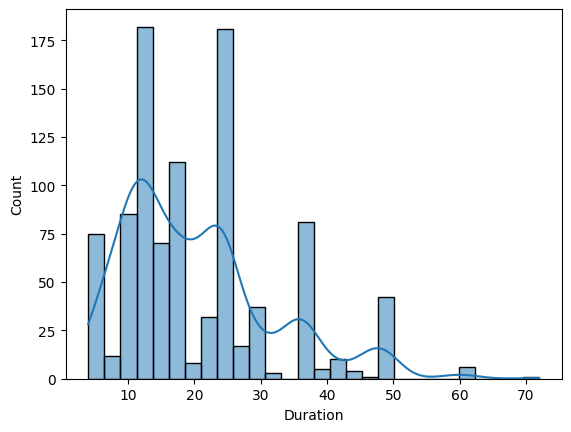

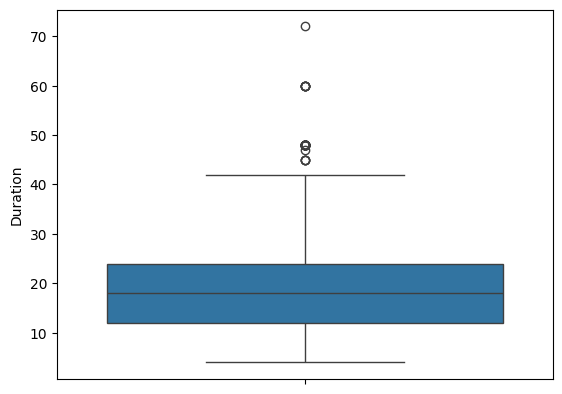

Group 2


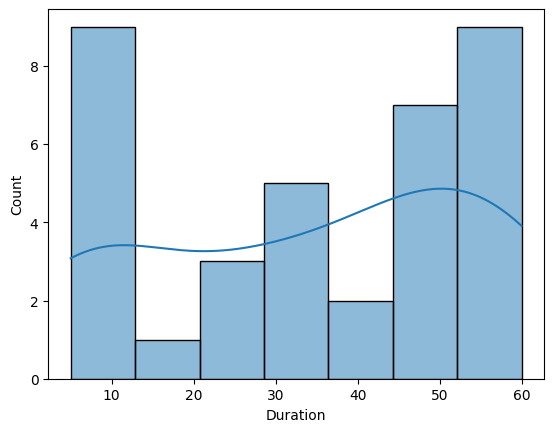

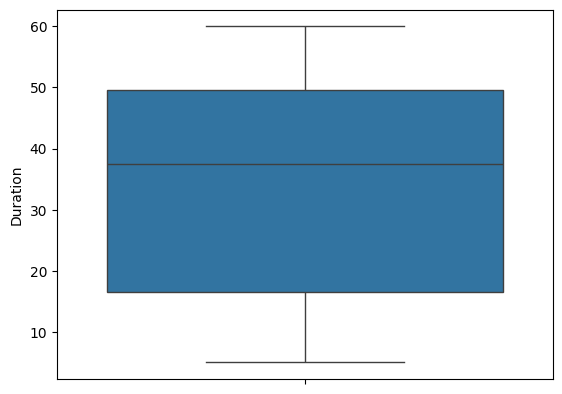

In [64]:
print("Group 1")
sns.histplot(data=df_group1, x='Duration', kde=True)
plt.show()

sns.boxplot(data=df_group1, y='Duration')
plt.show()

print("Group 2")
sns.histplot(data=df_group2, x='Duration', kde=True)
plt.show()

sns.boxplot(data=df_group2, y='Duration')
plt.show()

Group 1 is like the original dataset. The durations in group 2 are **diverse** too.

### Analyzing purpose

In [70]:
print("Group 1")
print(df_group1['Purpose'].value_counts())

print("\nGroup 2")
print(df_group2['Purpose'].value_counts())

Group 1
Purpose
car                    320
radio/TV               277
furniture/equipment    178
business                90
education               58
repairs                 20
domestic appliances     12
vacation/others          9
Name: count, dtype: int64

Group 2
Purpose
car                    17
business                7
radio/TV                3
vacation/others         3
furniture/equipment     3
repairs                 2
education               1
Name: count, dtype: int64


Group 1


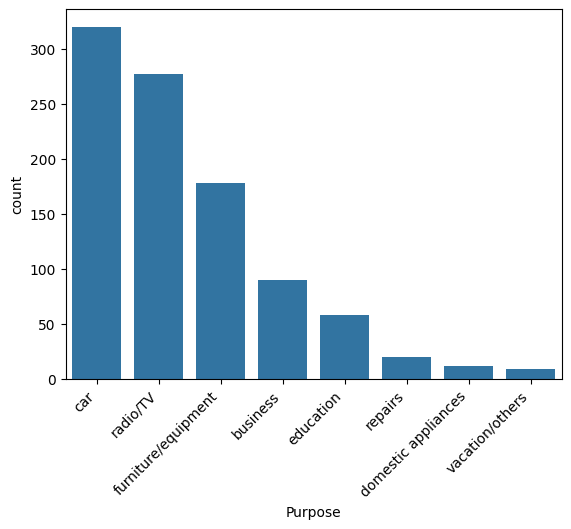

Group 2


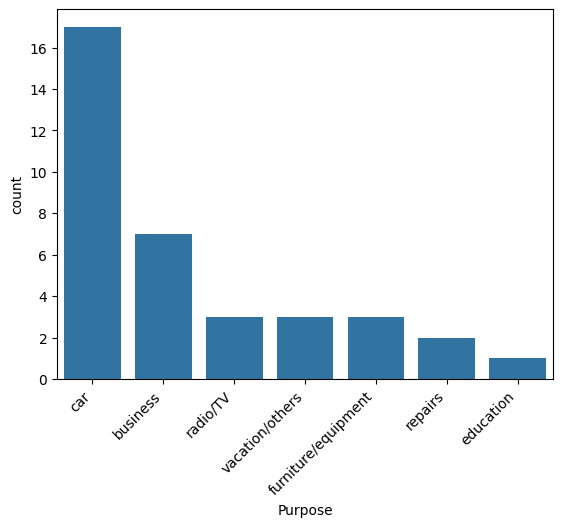

In [71]:
print("Group 1")
sns.countplot(data=df_group1, x='Purpose', order=df_group1['Purpose'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.show()

print("Group 2")
sns.countplot(data=df_group2, x='Purpose', order=df_group2['Purpose'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.show()

The dataset pattern is still represented by group 1. In group 2, **car continues to be the most requested purpose**, and all the other purposes are lesser now.